Nexus Global Retail Customer Churn

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [134]:
df=pd.read_csv("Customer_Churn_Project_Data.csv")

In [135]:
df.head()

,Customer_ID,Age,Gender,Annual_Income_USD,Total_Purchase_Amount,Purchase_Frequency_Per_Year,Support_Tickets_Opened,Subscription_Type,Days_Since_Last_Login,Email_Engagement_Rate,Region,Promotion_Response,Churn
0,1001,56.0,Non-binary,55887.153725,4604.854521,1,1,Standard,61,0.960821,Central,No,0
1,1002,69.0,Male,49035.237787,2242.378626,27,2,Standard,174,0.922702,South,No,1
2,1003,46.0,Non-binary,65778.947849,4711.784006,45,3,Basic,157,0.664085,North,No,0
3,1004,32.0,Male,52602.132012,2023.013275,22,1,Basic,200,0.213430,South,No,0
4,1005,60.0,Female,46155.711062,4763.695837,34,0,Basic,162,0.137884,North,No,0


In [136]:
df.isnull().sum()

Customer_ID                      0
Age                            600
Gender                           0
Annual_Income_USD              600
Total_Purchase_Amount            0
Purchase_Frequency_Per_Year      0
Support_Tickets_Opened           0
Subscription_Type                0
Days_Since_Last_Login            0
Email_Engagement_Rate            0
Region                           0
Promotion_Response               0
Churn                            0
dtype: int64

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  12000 non-null  int64  
 1   Age                          11400 non-null  float64
 2   Gender                       12000 non-null  object 
 3   Annual_Income_USD            11400 non-null  float64
 4   Total_Purchase_Amount        12000 non-null  float64
 5   Purchase_Frequency_Per_Year  12000 non-null  int64  
 6   Support_Tickets_Opened       12000 non-null  int64  
 7   Subscription_Type            12000 non-null  object 
 8   Days_Since_Last_Login        12000 non-null  int64  
 9   Email_Engagement_Rate        12000 non-null  float64
 10  Region                       12000 non-null  object 
 11  Promotion_Response           12000 non-null  object 
 12  Churn                        12000 non-null  int64  
dtypes: float64(4), i

In [138]:
df.describe()

,Customer_ID,Age,Annual_Income_USD,Total_Purchase_Amount,Purchase_Frequency_Per_Year,Support_Tickets_Opened,Days_Since_Last_Login,Email_Engagement_Rate,Churn
count,12000.00000,11400.000000,11400.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,7000.50000,46.058509,55263.205208,2544.483018,24.926000,2.006333,181.995250,0.501391,0.289917
std,3464.24595,16.401794,15020.083499,1418.861224,14.120109,1.426229,105.106276,0.290083,0.453742
min,1001.00000,18.000000,15000.000000,100.027130,1.000000,0.000000,0.000000,0.000028,0.000000
25%,4000.75000,32.000000,44976.156442,1311.580762,13.000000,1.000000,91.000000,0.249224,0.000000
50%,7000.50000,46.000000,55321.119625,2542.424848,25.000000,2.000000,183.000000,0.501455,0.000000
75%,10000.25000,60.000000,65509.561723,3777.146310,37.000000,3.000000,273.000000,0.756695,1.000000
max,13000.00000,74.000000,112100.760492,4999.463767,49.000000,9.000000,364.000000,0.999863,1.000000


In [139]:
df[df.duplicated(subset="Customer_ID",keep=False)]

,Customer_ID,Age,Gender,Annual_Income_USD,Total_Purchase_Amount,Purchase_Frequency_Per_Year,Support_Tickets_Opened,Subscription_Type,Days_Since_Last_Login,Email_Engagement_Rate,Region,Promotion_Response,Churn


In [140]:
print("max =",df["Age"].max(),
"min=",df["Age"].min())

max = 74.0 min= 18.0


<Axes: xlabel='Age'>

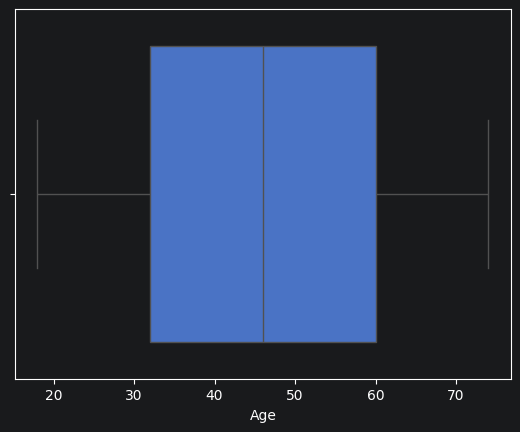

In [141]:
sns.boxplot(df,x="Age")

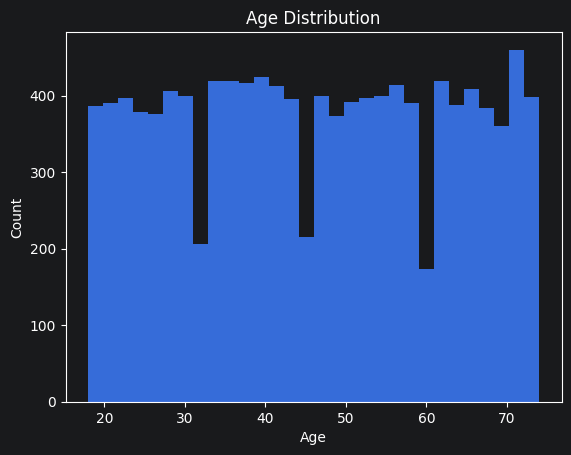

In [142]:
plt.hist(df['Age'], bins=30)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

In [143]:
New_age=df["Age"].fillna(df["Age"].mean())

In [144]:
New_age

0        56.0
1        69.0
2        46.0
3        32.0
4        60.0
         ... 
11995    58.0
11996    39.0
11997    58.0
11998    40.0
11999    24.0
Name: Age, Length: 12000, dtype: float64

In [145]:
nan_rows=df[df["Age"].isnull()]
print(nan_rows)

       Customer_ID  Age      Gender  Annual_Income_USD  Total_Purchase_Amount  \
16            1017  NaN      Female       66075.976736            4150.180184   
19            1020  NaN        Male       56196.245012             811.554193   
48            1049  NaN      Female       51735.966463            1993.598427   
67            1068  NaN        Male       57004.832516            1419.650826   
97            1098  NaN        Male       61904.925850            3861.085955   
...            ...  ...         ...                ...                    ...   
11924        12925  NaN  Non-binary       66426.982509             358.185045   
11944        12945  NaN        Male       31485.864819            2861.129702   
11946        12947  NaN      Female       50079.239909            4029.146209   
11976        12977  NaN        Male       66015.062024            2494.328984   
11977        12978  NaN        Male       46898.594406            3128.248347   

       Purchase_Frequency_P

In [146]:
New_age

0        56.0
1        69.0
2        46.0
3        32.0
4        60.0
         ... 
11995    58.0
11996    39.0
11997    58.0
11998    40.0
11999    24.0
Name: Age, Length: 12000, dtype: float64

In [147]:
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [148]:
df["Age"].isna().sum()

np.int64(0)

In [149]:
del New_age

In [150]:
df.head()

,Customer_ID,Age,Gender,Annual_Income_USD,Total_Purchase_Amount,Purchase_Frequency_Per_Year,Support_Tickets_Opened,Subscription_Type,Days_Since_Last_Login,Email_Engagement_Rate,Region,Promotion_Response,Churn
0,1001,56.0,Non-binary,55887.153725,4604.854521,1,1,Standard,61,0.960821,Central,No,0
1,1002,69.0,Male,49035.237787,2242.378626,27,2,Standard,174,0.922702,South,No,1
2,1003,46.0,Non-binary,65778.947849,4711.784006,45,3,Basic,157,0.664085,North,No,0
3,1004,32.0,Male,52602.132012,2023.013275,22,1,Basic,200,0.213430,South,No,0
4,1005,60.0,Female,46155.711062,4763.695837,34,0,Basic,162,0.137884,North,No,0


In [151]:
df["Gender"].unique()

array(['Non-binary', 'Male', 'Female'], dtype=object)

In [152]:
df["Gender"].value_counts()


Gender
Male          4015
Female        4006
Non-binary    3979
Name: count, dtype: int64

In [153]:
df["Annual_Income_USD"].isna().sum()

np.int64(600)

<Axes: xlabel='Annual_Income_USD'>

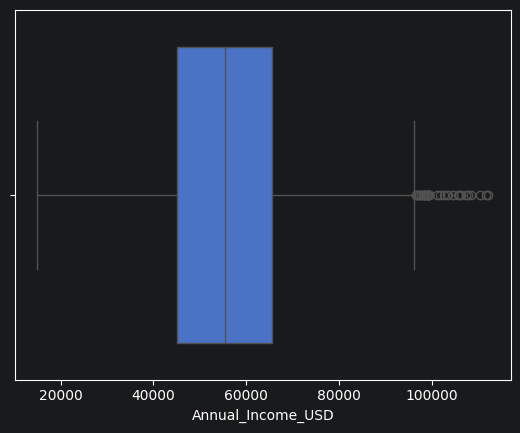

In [154]:
sns.boxplot(df,x="Annual_Income_USD")

In [155]:
(df["Annual_Income_USD"]<20000).sum()


np.int64(109)

<Axes: xlabel='Annual_Income_USD', ylabel='Count'>

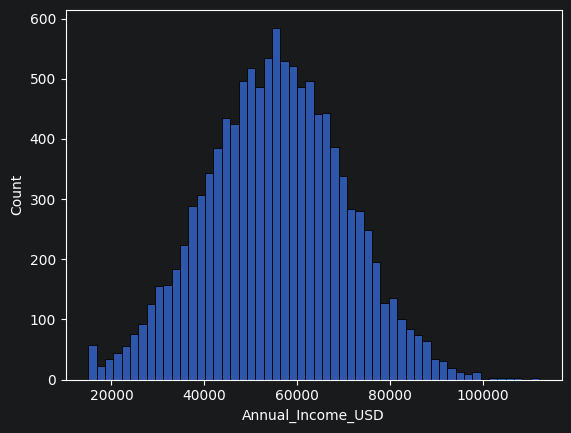

In [156]:
sns.histplot(df,x=df["Annual_Income_USD"])

In [157]:
q1=df["Annual_Income_USD"].quantile(0.25)
q3=df["Annual_Income_USD"].quantile(0.75)
IQR=q3-q1
lower = q1-1.5*IQR
upper = q3+1.5*IQR

In [158]:
outliers = df[(df['Annual_Income_USD'] < lower) | (df['Annual_Income_USD'] > upper)]

In [159]:
outliers["Annual_Income_USD"].values

array([101012.5316738 ,  98420.2619571 ,  97688.16175434,  98892.36007777,
        96576.84414237,  97013.15421414,  98248.16944507,  98544.12442758,
        99433.20796631, 107344.71414115,  96978.48868046, 105768.08289842,
       111662.34964192, 107705.14469598,  99261.47119909,  99039.62311957,
       103447.43690214, 103239.20864667, 108346.87111565,  96497.46233686,
       101698.77516847, 105649.50862941, 104450.76306166,  98807.35606631,
        98136.84826142,  99278.21842744, 102507.8521602 , 106120.76058769,
        99168.6943608 , 112100.76049179,  98294.93321826,  97710.60779268,
       110312.00202247,  97159.26886369])

In [160]:
upper = df["Annual_Income_USD"].quantile(0.95)

In [161]:
upper

np.float64(79939.16524482635)

In [162]:
outliers = df[(df['Annual_Income_USD'] < lower) | (df['Annual_Income_USD'] > upper)]

In [163]:
outliers

,Customer_ID,Age,Gender,Annual_Income_USD,Total_Purchase_Amount,Purchase_Frequency_Per_Year,Support_Tickets_Opened,Subscription_Type,Days_Since_Last_Login,Email_Engagement_Rate,Region,Promotion_Response,Churn
15,1016,57.0,Non-binary,86556.422154,4251.766244,29,4,Basic,294,0.494683,East,No,1
52,1053,21.0,Non-binary,81001.801999,3181.451217,4,1,Basic,328,0.279152,East,Yes,0
77,1078,59.0,Male,80653.755867,2980.496438,13,1,Basic,3,0.605866,West,No,0
120,1121,68.0,Female,80027.172465,3856.111515,47,1,Basic,331,0.255000,West,No,1
128,1129,56.0,Non-binary,80735.501393,3667.083980,29,0,Premium,251,0.703606,South,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11861,12862,48.0,Male,83677.203848,4359.422161,32,2,Basic,75,0.403437,North,No,0
11866,12867,30.0,Female,91291.985234,4734.309324,3,1,Basic,124,0.258662,Central,No,0
11955,12956,39.0,Non-binary,86033.955346,274.307293,47,1,Premium,14,0.709146,West,Yes,0
11965,12966,27.0,Non-binary,90061.177046,3073.102838,46,1,Premium,316,0.915140,North,Yes,1


In [164]:
df['Annual_Income_USD'] = df['Annual_Income_USD'].clip(lower=lower, upper=upper)

<Axes: xlabel='Annual_Income_USD'>

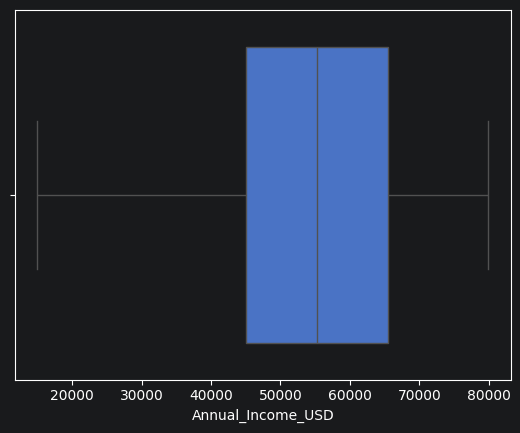

In [165]:
sns.boxplot(df,x="Annual_Income_USD")

In [166]:
df['Annual_Income_USD']

0        55887.153725
1        49035.237787
2        65778.947849
3        52602.132012
4        46155.711062
             ...     
11995    45326.570142
11996    59542.672589
11997    62327.112265
11998    46690.539320
11999    43026.086067
Name: Annual_Income_USD, Length: 12000, dtype: float64

In [167]:
df.describe()

,Customer_ID,Age,Annual_Income_USD,Total_Purchase_Amount,Purchase_Frequency_Per_Year,Support_Tickets_Opened,Days_Since_Last_Login,Email_Engagement_Rate,Churn
count,12000.00000,12000.000000,11400.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,7000.50000,46.058509,54950.762264,2544.483018,24.926000,2.006333,181.995250,0.501391,0.289917
std,3464.24595,15.986457,14372.616383,1418.861224,14.120109,1.426229,105.106276,0.290083,0.453742
min,1001.00000,18.000000,15000.000000,100.027130,1.000000,0.000000,0.000000,0.000028,0.000000
25%,4000.75000,33.000000,44976.156442,1311.580762,13.000000,1.000000,91.000000,0.249224,0.000000
50%,7000.50000,46.058509,55321.119625,2542.424848,25.000000,2.000000,183.000000,0.501455,0.000000
75%,10000.25000,59.000000,65509.561723,3777.146310,37.000000,3.000000,273.000000,0.756695,1.000000
max,13000.00000,74.000000,79939.165245,4999.463767,49.000000,9.000000,364.000000,0.999863,1.000000


In [171]:
df["Annual_Income_USD"].isna().sum()

np.int64(600)

In [172]:
# Compare mean vs median for your income column
print(f"Mean income: ${df['Annual_Income_USD'].mean():,.2f}")
print(f"Median income: ${df['Annual_Income_USD'].median():,.2f}")
print(f"Difference: ${df['Annual_Income_USD'].mean() - df['Annual_Income_USD'].median():,.2f}")

Mean income: $54,950.76
Median income: $55,321.12
Difference: $-370.36


<Axes: xlabel='Annual_Income_USD', ylabel='Count'>

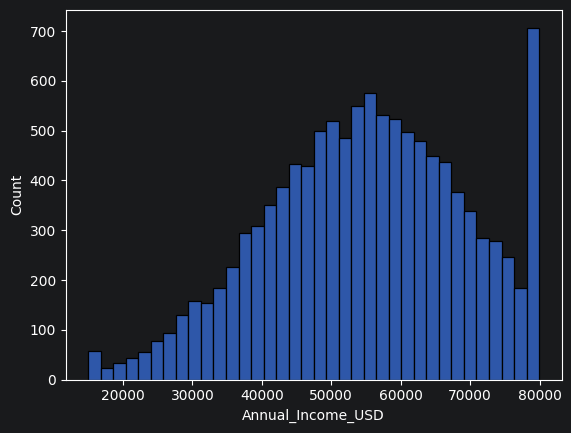

In [173]:
sns.histplot(df,x=df["Annual_Income_USD"])

In [175]:
median_income=df["Annual_Income_USD"].fillna(df["Annual_Income_USD"].median())


In [176]:
median_income

0        55887.153725
1        49035.237787
2        65778.947849
3        52602.132012
4        46155.711062
             ...     
11995    45326.570142
11996    59542.672589
11997    62327.112265
11998    46690.539320
11999    43026.086067
Name: Annual_Income_USD, Length: 12000, dtype: float64

In [177]:
df["Annual_Income_USD"]=df["Annual_Income_USD"].fillna(df["Annual_Income_USD"].median())

In [178]:
df["Annual_Income_USD"].isna().sum()

np.int64(0)

In [179]:
del median_income

In [180]:
df.head()

,Customer_ID,Age,Gender,Annual_Income_USD,Total_Purchase_Amount,Purchase_Frequency_Per_Year,Support_Tickets_Opened,Subscription_Type,Days_Since_Last_Login,Email_Engagement_Rate,Region,Promotion_Response,Churn
0,1001,56.0,Non-binary,55887.153725,4604.854521,1,1,Standard,61,0.960821,Central,No,0
1,1002,69.0,Male,49035.237787,2242.378626,27,2,Standard,174,0.922702,South,No,1
2,1003,46.0,Non-binary,65778.947849,4711.784006,45,3,Basic,157,0.664085,North,No,0
3,1004,32.0,Male,52602.132012,2023.013275,22,1,Basic,200,0.213430,South,No,0
4,1005,60.0,Female,46155.711062,4763.695837,34,0,Basic,162,0.137884,North,No,0


<Axes: xlabel='Total_Purchase_Amount'>

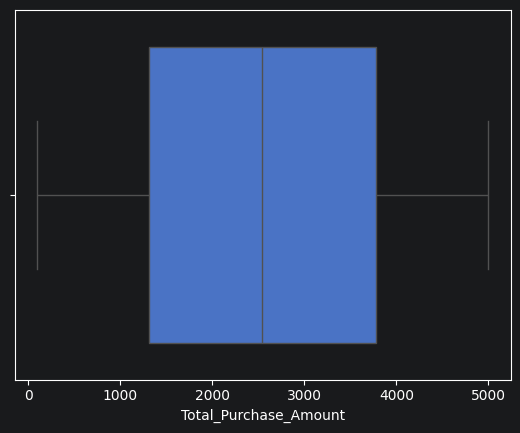

In [182]:
df["Total_Purchase_Amount"].isna().sum()
sns.boxplot(df,x="Total_Purchase_Amount")

In [183]:
print('max=',max(df["Total_Purchase_Amount"]))
print('min=',min(df["Total_Purchase_Amount"]))

max= 4999.463766693823
min= 100.02712971111616


In [184]:
q1 = df["Total_Purchase_Amount"].quantile(0.25)
q3 = df["Total_Purchase_Amount"].quantile(0.75)
IQR = q3 - q1
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR
outliers = df[(df['Total_Purchase_Amount'] < lower) | (df['Total_Purchase_Amount'] > upper)]

In [185]:
outliers

,Customer_ID,Age,Gender,Annual_Income_USD,Total_Purchase_Amount,Purchase_Frequency_Per_Year,Support_Tickets_Opened,Subscription_Type,Days_Since_Last_Login,Email_Engagement_Rate,Region,Promotion_Response,Churn


In [186]:
df["Purchase_Frequency_Per_Year"].min()

np.int64(1)

In [187]:
df["Purchase_Frequency_Per_Year"].max()

np.int64(49)

In [188]:
df["Subscription_Type"].unique()

array(['Standard', 'Basic', 'Premium'], dtype=object)

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  12000 non-null  int64  
 1   Age                          12000 non-null  float64
 2   Gender                       12000 non-null  object 
 3   Annual_Income_USD            12000 non-null  float64
 4   Total_Purchase_Amount        12000 non-null  float64
 5   Purchase_Frequency_Per_Year  12000 non-null  int64  
 6   Support_Tickets_Opened       12000 non-null  int64  
 7   Subscription_Type            12000 non-null  object 
 8   Days_Since_Last_Login        12000 non-null  int64  
 9   Email_Engagement_Rate        12000 non-null  float64
 10  Region                       12000 non-null  object 
 11  Promotion_Response           12000 non-null  object 
 12  Churn                        12000 non-null  int64  
dtypes: float64(4), i

In [190]:
df["Age"]=df["Age"].astype(int)

In [195]:
le=LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])



In [197]:
df["Gender"]
print(f"Classes found: {le.classes_}")

Classes found: ['Female' 'Male' 'Non-binary']


In [198]:
df["Subscription_Type"]=le.fit_transform(df["Subscription_Type"])

In [199]:
df["Region"].unique()

array(['Central', 'South', 'North', 'East', 'West'], dtype=object)

In [201]:
ohe=OneHotEncoder()
df["Region"]=le.fit_transform(df["Region"])

In [202]:
df["Region"]

0        0
1        3
2        2
3        3
4        2
        ..
11995    4
11996    1
11997    4
11998    4
11999    4
Name: Region, Length: 12000, dtype: int64

In [203]:
df["Promotion_Response"]=le.fit_transform(df["Promotion_Response"])

In [204]:
df.head()

,Customer_ID,Age,Gender,Annual_Income_USD,Total_Purchase_Amount,Purchase_Frequency_Per_Year,Support_Tickets_Opened,Subscription_Type,Days_Since_Last_Login,Email_Engagement_Rate,Region,Promotion_Response,Churn
0,1001,56,2,55887.153725,4604.854521,1,1,2,61,0.960821,0,0,0
1,1002,69,1,49035.237787,2242.378626,27,2,2,174,0.922702,3,0,1
2,1003,46,2,65778.947849,4711.784006,45,3,0,157,0.664085,2,0,0
3,1004,32,1,52602.132012,2023.013275,22,1,0,200,0.213430,3,0,0
4,1005,60,0,46155.711062,4763.695837,34,0,0,162,0.137884,2,0,0


In [216]:
df['Promotion_Response'].value_counts()

Promotion_Response
0    9565
1    2435
Name: count, dtype: int64